In [1]:
import pandas as pd

In [7]:
data=pd.read_csv(r'C:\Users\laksn\CodeAlpha-java-projects\loan_dataset.csv')
data.head(50)

,income,loan_amount,term,credit_history,default
0,55000.0,15000,36,1.0,0
1,NaN,8000,24,0.0,1
2,78000.0,25000,60,1.0,0
3,45000.0,12000,36,0.0,0
4,28000.0,7500,24,0.0,1
5,92000.0,40000,60,1.0,0
6,NaN,10000,36,0.0,1
7,NaN,20000,48,1.0,0
8,NaN,9000,24,0.0,1
9,85000.0,35000,60,1.0,0


In [10]:
data.shape

(50, 5)

In [11]:
data.columns.tolist()

['income', 'loan_amount', 'term', 'credit_history', 'default']

In [12]:
data.dtypes

income            float64
loan_amount         int64
term                int64
credit_history    float64
default             int64
dtype: object

In [13]:
data.isnull().sum()

income            8
loan_amount       0
term              0
credit_history    0
default           0
dtype: int64

In [15]:
data.fillna({'income':data['income'].median()},inplace=True)

,income,loan_amount,term,credit_history,default
0,55000.0,15000,36,1.0,0
1,51000.0,8000,24,0.0,1
2,78000.0,25000,60,1.0,0
3,45000.0,12000,36,0.0,0
4,28000.0,7500,24,0.0,1
5,92000.0,40000,60,1.0,0
6,51000.0,10000,36,0.0,1
7,51000.0,20000,48,1.0,0
8,51000.0,9000,24,0.0,1
9,85000.0,35000,60,1.0,0


In [16]:
data.isnull().sum()

income            0
loan_amount       0
term              0
credit_history    0
default           0
dtype: int64

In [18]:
data.describe()

,income,loan_amount,term,credit_history,default
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,55200.000000,18330.000000,39.840000,0.480000,0.380000
std,19944.821843,11526.106127,13.593756,0.504672,0.490314
min,25000.000000,5800.000000,24.000000,0.000000,0.000000
25%,42250.000000,9275.000000,24.000000,0.000000,0.000000
50%,51000.000000,13750.000000,36.000000,0.000000,0.000000
75%,70750.000000,24500.000000,48.000000,1.000000,1.000000
max,98000.000000,48000.000000,60.000000,1.000000,1.000000


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

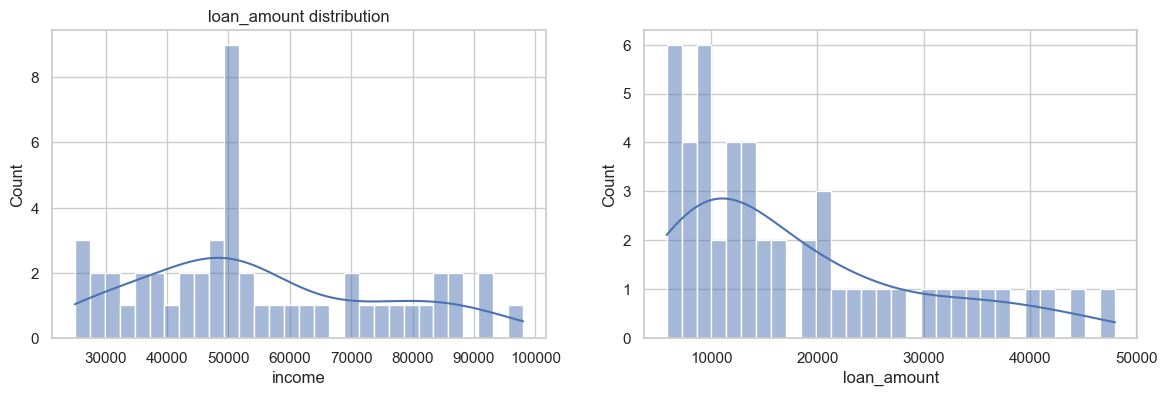

In [23]:
sns.set(style='whitegrid')
fig,axes=plt.subplots(1,2,figsize=(14,4))
sns.histplot(data['income'],kde=True,bins=30,ax=axes[0])
axes[0].set_title("income distribution")

sns.histplot(data['loan_amount'],kde=True,bins=30,ax=axes[1])
axes[0].set_title("loan_amount distribution")

plt.tight_layout
plt.show()

In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

Text(0.5, 1.0, 'feature correlation heatmap')

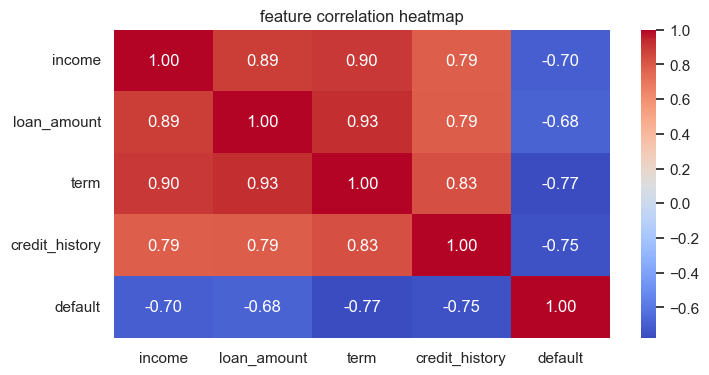

In [27]:
plt.figure(figsize=(8,4))
sns.heatmap(data.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt=".2f")
plt.title("feature correlation heatmap")

In [28]:
data['term binary']=data['term'].apply(lambda x:1 if x==60 else 0)

In [29]:
import numpy as np
data['log_income']=np.log1p(data['income'])
data['log_loan_amount']=np.log1p(data['loan_amount'])

In [30]:
features=['log_income','log_loan_amount','credit_history']
target='default'

In [31]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scale_feature=['log_income','log_loan_amount']
data[scale_feature]=scaler.fit_transform(data[scale_feature])
data.head()

,income,loan_amount,term,credit_history,default,term binary,log_income,log_loan_amount
0,55000.0,15000,36,1.0,0,0,0.168811,-0.031204
1,51000.0,8000,24,0.0,1,0,-0.036904,-1.080356
2,78000.0,25000,60,1.0,0,1,1.120662,0.821401
3,45000.0,12000,36,0.0,0,0,-0.377901,-0.403639
4,28000.0,7500,24,0.0,1,0,-1.670515,-1.188067


In [33]:
from sklearn.model_selection import train_test_split
x=data[features]
y=data[target]
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report,accuracy_score

In [38]:
models={
    'LogisticRegression':LogisticRegression(max_iter=1000,random_state=42),
    'DecisionTreeClassifier':DecisionTreeClassifier(random_state=42),
    'RandomForestClassifier':RandomForestClassifier(n_estimators=100,random_state=42)
}

In [40]:
for name,model in models.items():
    print(f"model name:{name}")
    pipeline=Pipeline([('classifier',model)])
    pipeline.fit(X_train,y_train)
    ypred=pipeline.predict(X_test)
    print(f"Accuray:{accuracy_score(y_test,ypred):.4f}")
    print("classification_report")
    print(classification_report(y_test,ypred))

model name:LogisticRegression
Accuray:1.0000
classification_report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

model name:DecisionTreeClassifier
Accuray:0.9000
classification_report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       1.00      0.50      0.67         2

    accuracy                           0.90        10
   macro avg       0.94      0.75      0.80        10
weighted avg       0.91      0.90      0.89        10

model name:RandomForestClassifier
Accuray:1.0000
classification_report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00     